In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
graak = pd.read_csv("../data/combine/graank_combine.csv")

In [4]:
graak = graak.drop('Unnamed: 0', axis=1)

In [5]:
df  = graak[graak['sup_min']>= 0.3]

In [6]:
df

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm
8,9.638912,0.30,150,50.364258,HCV,Graank
9,9.240743,0.34,120,39.067383,HCV,Graank
10,8.967299,0.38,94,30.809570,HCV,Graank
11,8.862499,0.40,94,30.036133,HCV,Graank
12,7.565296,0.50,48,20.431641,HCV,Graank
...,...,...,...,...,...,...
125,8.494632,0.60,112,38.968750,PCA Chickenpox,Graank
126,7.503642,0.70,44,19.597656,PCA Chickenpox,Graank
127,7.109069,0.80,0,4.356445,PCA Chickenpox,Graank
128,7.121989,0.90,0,4.856445,PCA Chickenpox,Graank


In [37]:
df

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm
8,9.638912,0.30,150,50.364258,HCV,Graank
9,9.240743,0.34,120,39.067383,HCV,Graank
10,8.967299,0.38,94,30.809570,HCV,Graank
11,8.862499,0.40,94,30.036133,HCV,Graank
12,7.565296,0.50,48,20.431641,HCV,Graank
...,...,...,...,...,...,...
125,8.494632,0.60,112,38.968750,PCA Chickenpox,Graank
126,7.503642,0.70,44,19.597656,PCA Chickenpox,Graank
127,7.109069,0.80,0,4.356445,PCA Chickenpox,Graank
128,7.121989,0.90,0,4.856445,PCA Chickenpox,Graank


In [7]:
df['Status'] = df['dataset'].apply(lambda x: 'ACP' if str(x).startswith('PCA') else 'Sans ACP')
df['dataset'] = df['dataset'].str.replace(r'^PCA', '', regex=True).str.strip()


/tmp/ipykernel_194618/3649515965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Status'] = df['dataset'].apply(lambda x: 'ACP' if str(x).startswith('PCA') else 'Sans ACP')
/tmp/ipykernel_194618/3649515965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dataset'] = df['dataset'].str.replace(r'^PCA', '', regex=True).str.strip()


In [8]:
df['dataset'] = df['dataset'].apply(lambda x: "Air Quality" if x == 'Air Quailty' else x)

/tmp/ipykernel_194618/826042045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dataset'] = df['dataset'].apply(lambda x: "Air Quality" if x == 'Air Quailty' else x)


In [9]:
df[df['dataset'] =='Air Quailty']

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm,Status


In [10]:
filenames = ['HCV', 'Air Quality', 'Cargo 2000', 'Chickenpox']

In [42]:
for i, file in enumerate(filenames):
    print(i)

0
1
2
3


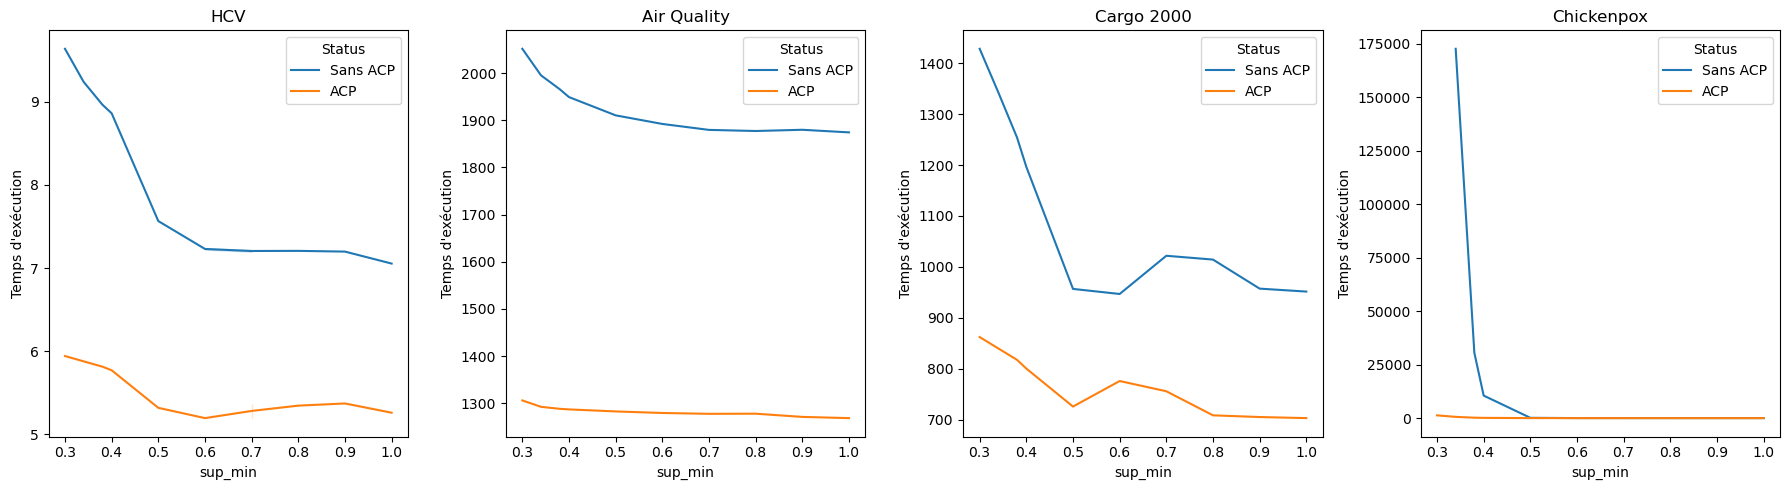

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
datasets = df.dataset.unique()

for i, file in enumerate(filenames):
    df_tmp = df[df['dataset'] == file]

    sns.lineplot(data=df_tmp, x='sup_min', y='execution_time', ax=axes[i], hue='Status')
    axes[i].set_title(file)
    axes[i].set_ylabel("Temps d'exécution")

# Ajustement
plt.tight_layout()
plt.show()


In [11]:

def plot_metrics(df, filenames, algorithme_name ='Graank',col_supp ='sup_min', col_time ='execution_time', col_memory='memory_usage',col_candidate = 'number of patterns',  n_rows=3, n_cols=4, figsize=(20, 8)):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Si axes est 2D, sinon convertir en 2D pour uniformiser
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    print(df[col_supp].unique())
    for i, file in enumerate(filenames):

        
        df_tmp = df[df['dataset'] == file]

        sns.lineplot(data=df_tmp, x=col_supp, y=col_time, hue='Status', ax=axes[0, i])
        axes[0, i].set_title(f"{file} - Tme")
        axes[0, i].set_xlabel("Min sup")
        axes[0, i].set_ylabel("Time (s)")
        
        sns.lineplot(data=df_tmp, x=col_supp, y=col_memory, hue='Status', ax=axes[1, i])
        axes[1, i].set_title(f"{file} - Memory")
        axes[1, i].set_xlabel("Min sup")
        axes[1, i].set_ylabel("Memory (KB)")

        sns.lineplot(data=df_tmp, x=col_supp, y=col_candidate, hue='Status', ax=axes[2, i])
        axes[2, i].set_title(f"{file} - Candidats")
        axes[2, i].set_xlabel("Min sup")
        axes[2, i].set_ylabel("# candidats")

    plt.suptitle(algorithme_name, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"../images_conf/{algorithme_name}_fr_metrics.eps")
    plt.show()


In [12]:
df['dataset'].unique()

array(['HCV', 'Air Quality', 'Cargo 2000', 'Chickenpox'], dtype=object)

[0.3  0.34 0.38 0.4  0.5  0.6  0.7  0.8  0.9  1.  ]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


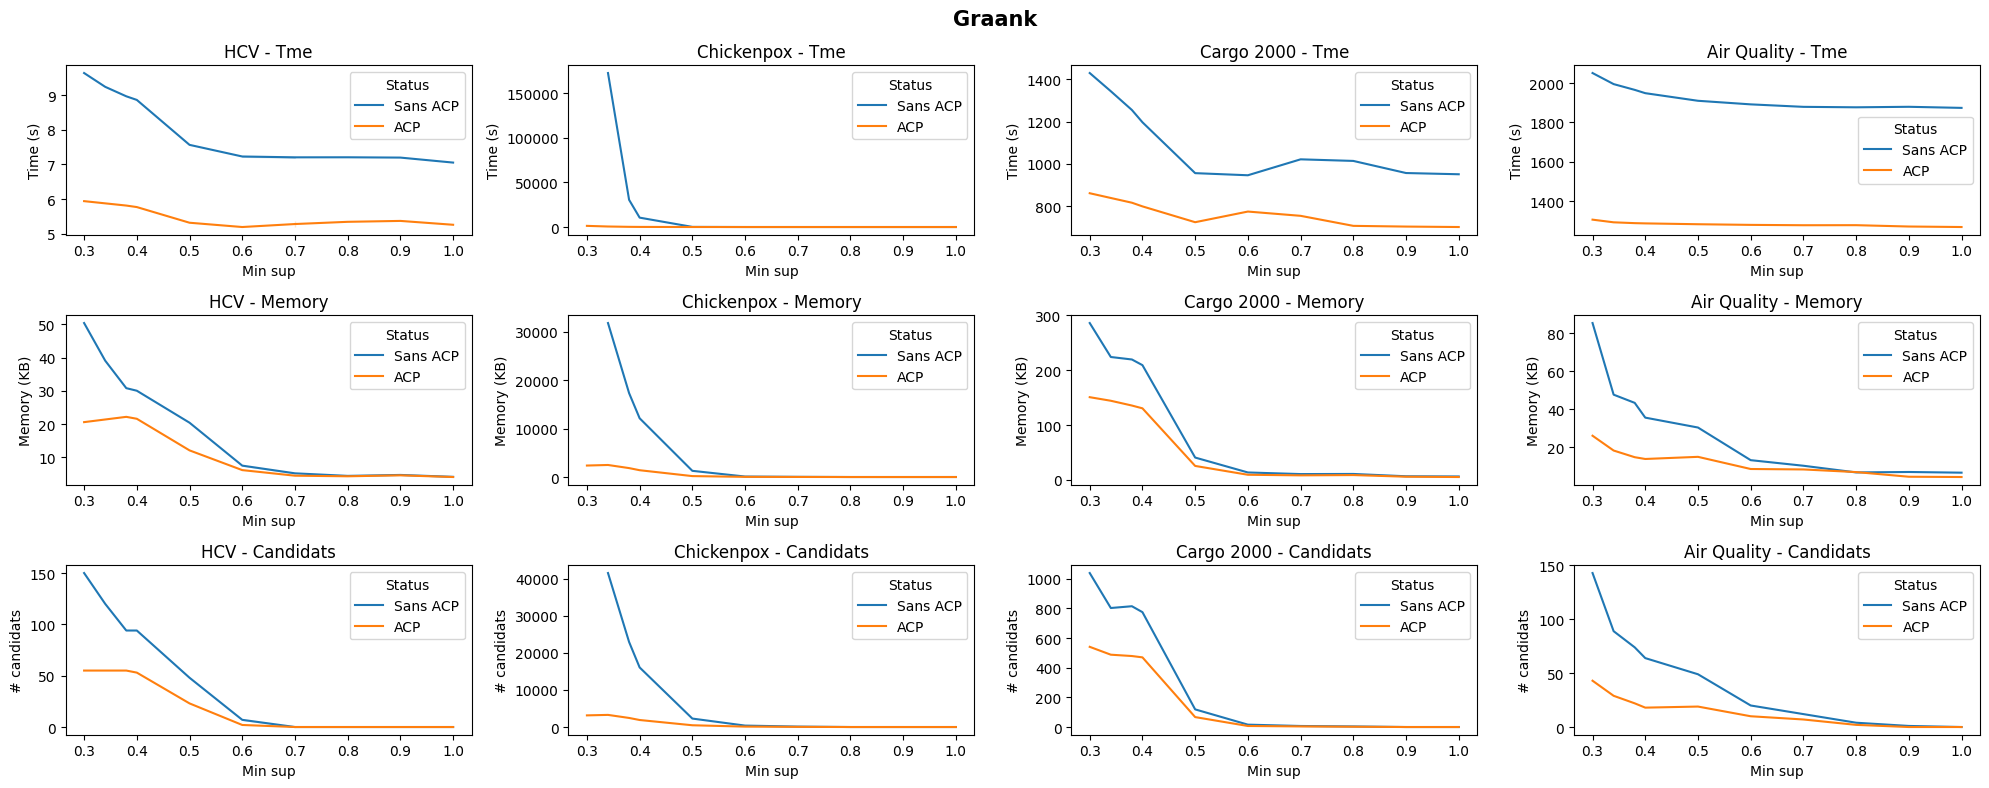

In [13]:
filenames = ['HCV','Chickenpox', 'Cargo 2000', 'Air Quality']
plot_metrics(df, filenames,algorithme_name='Graank', n_rows=3, n_cols=4, figsize=(20,8))


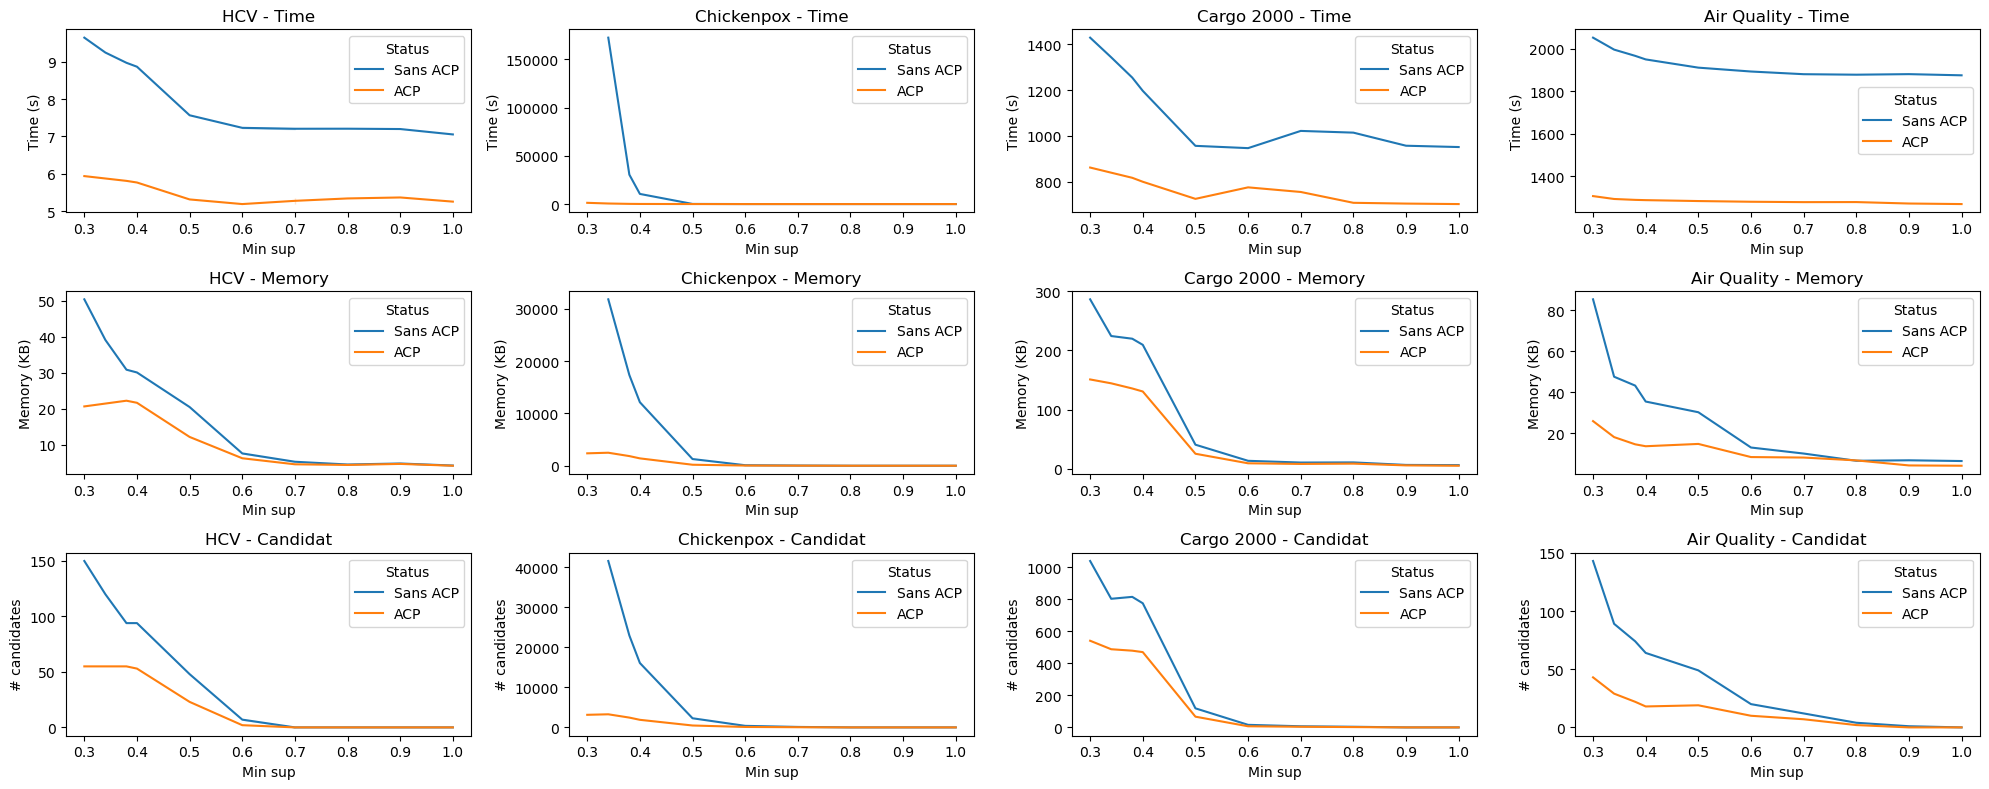

In [47]:
fig, axes = plt.subplots(3, 4, figsize=(20, 8))
datasets = df.dataset.unique()

for i, file in enumerate(filenames):
    df_tmp = df[df['dataset'] == file]

    # Ligne 1 : temps
    sns.lineplot(data=df_tmp, x='sup_min', y='execution_time', hue='Status', ax=axes[0, i])
    axes[0, i].set_title(f"{file} - Time")
    axes[0, i].set_xlabel("Min sup")
    axes[0, i].set_ylabel("Time (s)")
    axes[0, i].set_xlabel("Min sup")
    # Ligne 2 : mémoire
    sns.lineplot(data=df_tmp, x='sup_min', y='memory_usage', hue='Status', ax=axes[1, i])
    axes[1, i].set_title(f"{file} - Memory")
    axes[1, i].set_ylabel("Memory (KB)")
    axes[1, i].set_xlabel("Min sup")
    
    
    sns.lineplot(data=df_tmp, x='sup_min', y='number of patterns', hue='Status', ax=axes[2, i])
    axes[2, i].set_title(f"{file} - Candidat")
    axes[2, i].set_ylabel("# candidates")
    axes[2, i].set_xlabel("Min sup")

plt.tight_layout()
plt.show()


In [48]:
para = pd.read_csv("../data/combine/paraminer.csv")

In [49]:
para['Status'] = para['method'].apply(lambda x: 'NoPCA' if x=='Clean' else 'PCA')

In [50]:
para.dataset.unique()

array(['Chickenpox', 'HCV', 'Air_quality', 'Cargo_2000'], dtype=object)

In [51]:
filename_paras =['HCV', 'Chickenpox', 'Cargo_2000','Air_quality']

In [52]:
para[para['dataset'] == 'Cargo_2000']

,time,patterns,memory_kb,algo,dataset,support,method,Status
3,136740,37,3200,Paraminer,Cargo_2000,0.8,Clean,NoPCA
14,188277,40,3272,Paraminer,Cargo_2000,0.6,Clean,NoPCA
17,136664,37,3368,Paraminer,Cargo_2000,0.9,Clean,NoPCA
18,135179,37,3308,Paraminer,Cargo_2000,0.7,Clean,NoPCA
19,223960,56,3204,Paraminer,Cargo_2000,0.4,Clean,NoPCA
24,3839861,8228,3216,Paraminer,Cargo_2000,0.3,Clean,NoPCA
26,197166,41,3368,Paraminer,Cargo_2000,0.5,Clean,NoPCA
31,26475,8,3344,Paraminer,Cargo_2000,0.8,PCA,PCA
42,25156,8,3232,Paraminer,Cargo_2000,0.6,PCA,PCA
45,25600,8,3360,Paraminer,Cargo_2000,0.9,PCA,PCA


[0.6 0.4 0.8 0.3 0.7 0.5 0.9]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


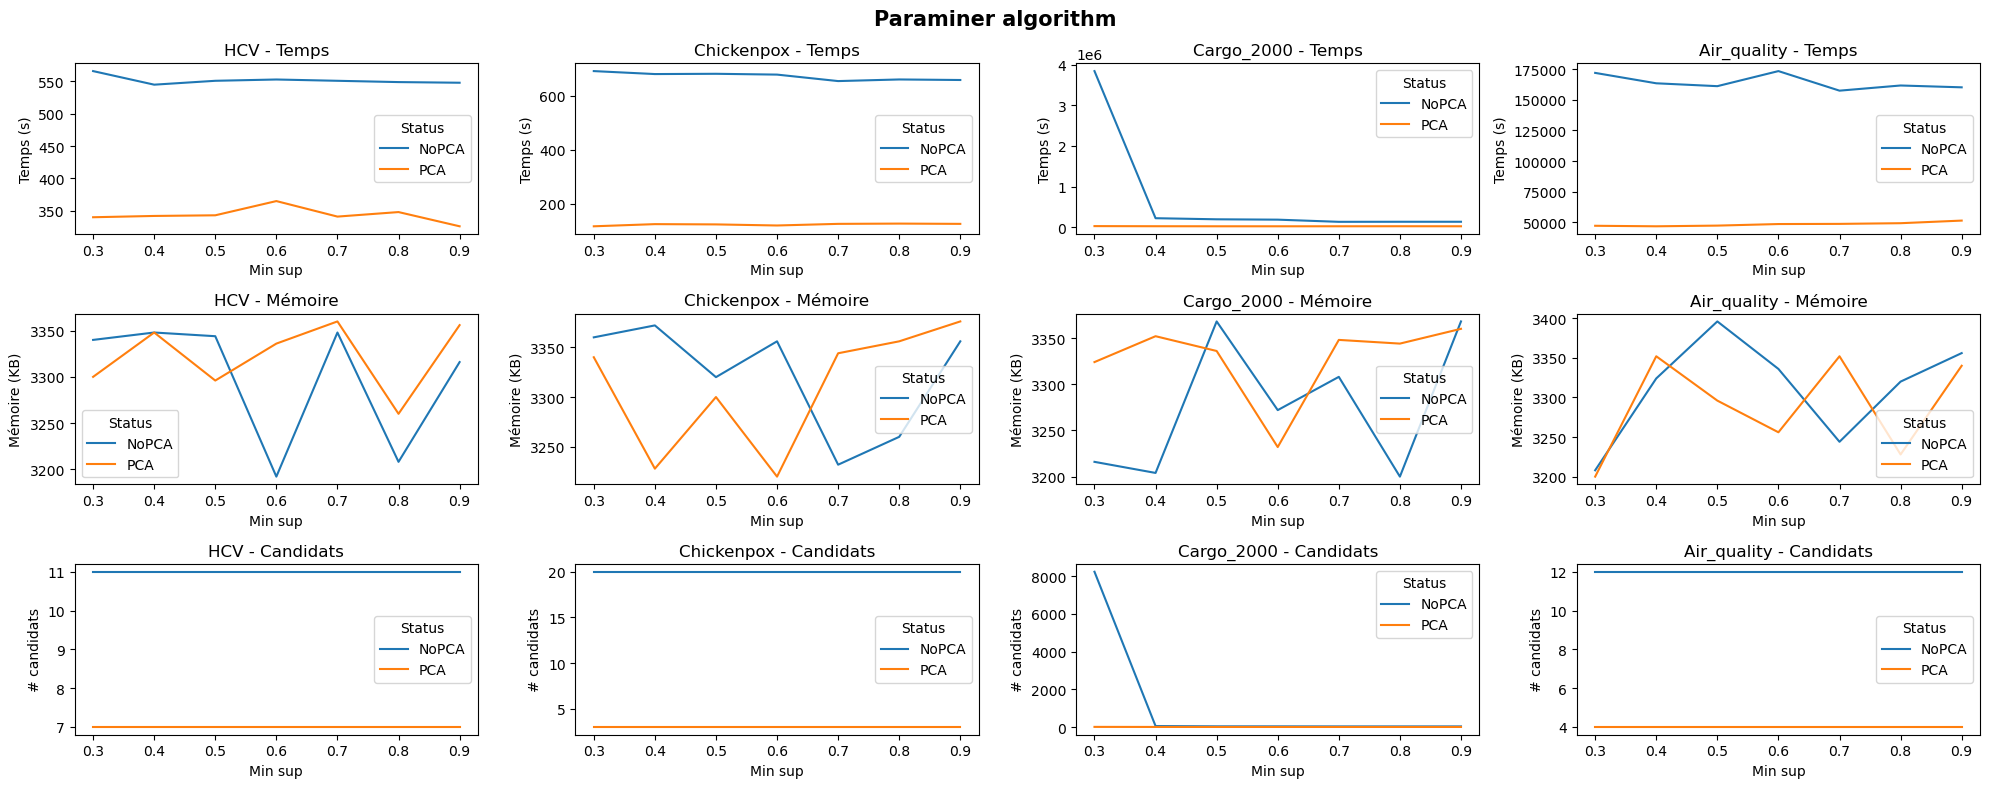

In [53]:
plot_metrics(para, filename_paras, algorithme_name='Paraminer algorithm', n_rows=3, n_cols=4, figsize=(20,8), col_supp='support', col_candidate='patterns', col_time='time', col_memory="memory_kb")

In [54]:
prun = pd.read_csv("../data/combine/Pruning_paraminer.csv")

In [55]:
prun.head()

,time,patterns,memory_kb,algo,dataset,support,method
0,679,20,3252,Paraminer+pruning,Chickenpox,0.6,Clean
1,165137,12,3352,Paraminer+pruning,Air_quality,0.9,Clean
2,163113,12,3284,Paraminer+pruning,Air_quality,0.7,Clean
3,697,20,3316,Paraminer+pruning,Chickenpox,0.3,Clean
4,242665,56,3296,Paraminer+pruning,Cargo_2000,0.4,Clean


In [56]:
prun[prun['dataset'] =='Cargo_2000']

,time,patterns,memory_kb,algo,dataset,support,method
4,242665,56,3296,Paraminer+pruning,Cargo_2000,0.4,Clean
6,144745,37,3392,Paraminer+pruning,Cargo_2000,0.9,Clean
8,206101,41,3320,Paraminer+pruning,Cargo_2000,0.5,Clean
15,205835,40,3224,Paraminer+pruning,Cargo_2000,0.6,Clean
18,143018,37,3324,Paraminer+pruning,Cargo_2000,0.8,Clean
20,4325027,8228,3352,Paraminer+pruning,Cargo_2000,0.3,Clean
27,139411,37,3336,Paraminer+pruning,Cargo_2000,0.7,Clean
32,27362,9,3356,Paraminer+pruning,Cargo_2000,0.4,PCA
34,24935,8,3304,Paraminer+pruning,Cargo_2000,0.9,PCA
36,25982,8,3364,Paraminer+pruning,Cargo_2000,0.5,PCA


In [57]:
files_pru  =['HCV', 'Chickenpox', 'Cargo_2000','Air_quality']

In [58]:
prun['Status'] = prun['method'].apply(lambda x: 'NoPCA' if x=='Clean' else 'PCA')

[0.6 0.9 0.7 0.3 0.4 0.5 0.8]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


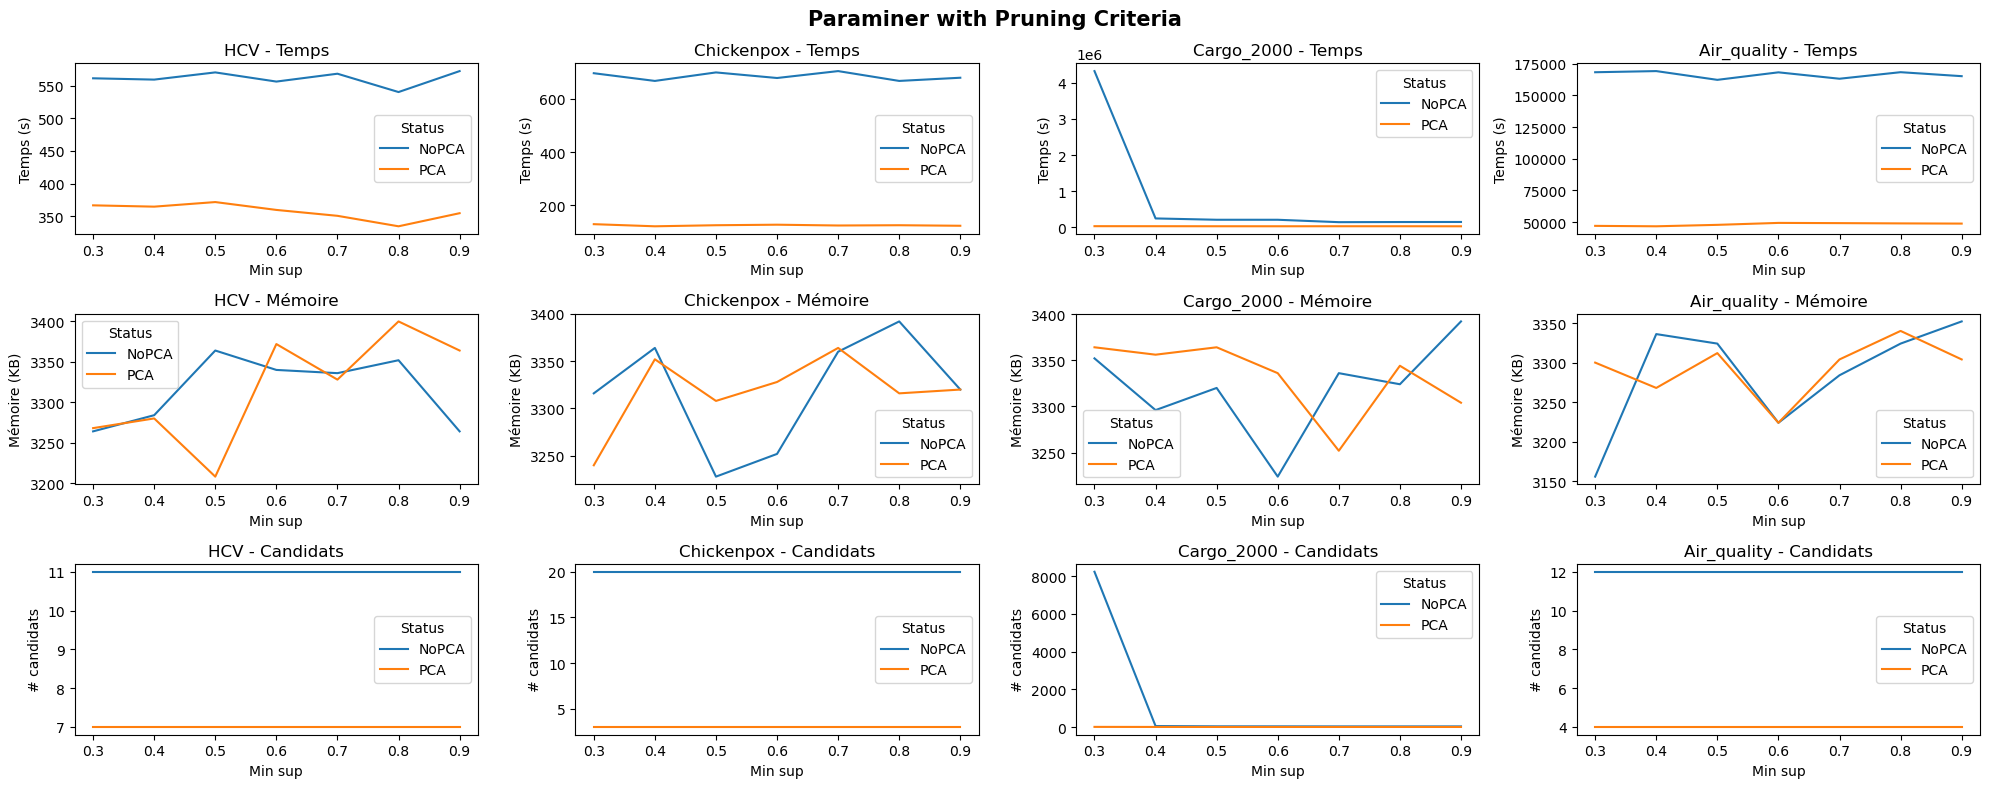

In [59]:
plot_metrics(prun, files_pru, algorithme_name='Paraminer with Pruning Criteria', n_rows=3, n_cols=4, figsize=(20,8), col_supp='support', col_candidate='patterns', col_time='time', col_memory="memory_kb")

In [60]:
pru_gr = pd.read_csv('../data/combine/pruning_grite.csv')

In [61]:
pru_gr

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm
0,4568.143451,0.10,148,4568.143451,HCV,Grite+pruning
1,600.380242,0.80,0,600.380242,HCV,Grite+pruning
2,655.148236,0.16,0,655.148236,HCV,Grite+pruning
3,14266.296674,0.04,556,14266.296674,HCV,Grite+pruning
4,4566.153875,0.70,0,4566.153875,HCV,Grite+pruning
5,578.645409,0.40,0,578.645409,HCV,Grite+pruning
6,614.519358,0.24,0,614.519358,HCV,Grite+pruning
7,4542.190836,0.90,0,4542.190836,HCV,Grite+pruning
8,716.779630,0.14,16,716.779630,HCV,Grite+pruning
9,428.260051,0.28,0,428.260051,HCV,Grite+pruning
